1. DENSE - KLASYFIKACJA IRIS Z WARTOSCIA DROPOUT 0.5

In [1]:
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# wczytanie zbioru danych
iris = load_iris()
X = iris.data
y = iris.target

# podzial na treningowy oi testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# standaryzacja danych
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(4,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [3]:
history = model.fit(X_train, y_train, epochs=50, validation_split=0.2)
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Accuracy:", test_acc)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.3958 - loss: 1.0965 - val_accuracy: 0.2083 - val_loss: 1.1578
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4688 - loss: 1.0444 - val_accuracy: 0.2500 - val_loss: 1.1140
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5104 - loss: 0.9712 - val_accuracy: 0.2500 - val_loss: 1.0713
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5625 - loss: 0.9353 - val_accuracy: 0.3750 - val_loss: 1.0318
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6042 - loss: 0.8773 - val_accuracy: 0.5000 - val_loss: 0.9938
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6458 - loss: 0.8728 - val_accuracy: 0.5417 - val_loss: 0.9577
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6667 - loss: 0.8123 - val_accuracy: 0.5000 - val_loss: 0.9243
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7708 - loss: 0.7646 - val_accuracy: 0.5417 - val_loss: 0.8938

2. CONV2D - CNN DLA ZBIORU MNIST Z WIĘKSZĄ LICZBĄ WARSTW KONWOLUCYJNYCH

In [4]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0

In [6]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
model.fit(x_train, y_train, epochs=5, validation_split=0.1)
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Accuracy:", test_acc)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 35ms/step - accuracy: 0.9641 - loss: 0.1152 - val_accuracy: 0.9840 - val_loss: 0.0517
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.9879 - loss: 0.0390 - val_accuracy: 0.9873 - val_loss: 0.0413
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 36ms/step - accuracy: 0.9915 - loss: 0.0267 - val_accuracy: 0.9902 - val_loss: 0.0343
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 35ms/step - accuracy: 0.9933 - loss: 0.0195 - val_accuracy: 0.9895 - val_loss: 0.0373
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.9952 - loss: 0.0149 - val_accuracy: 0.9900 - val_loss: 0.0431
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9917 - loss: 0.0292
Accuracy: 0.9916999936103821


3. LSTM - ANALIZA SENTYMENTU Z EMBEDDINGIEM O MNIEJSZYM WYMIARZE: 16

In [8]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


C:\Users\przem\data_env\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [10]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(200,)),
    tf.keras.layers.Embedding(input_dim=10000, output_dim=16),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [11]:
model.fit(x_train, y_train, epochs=3, validation_split=0.2)
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Accuracy:", test_acc)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 84ms/step - accuracy: 0.7435 - loss: 0.5075 - val_accuracy: 0.8068 - val_loss: 0.4215
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - accuracy: 0.8841 - loss: 0.2954 - val_accuracy: 0.8634 - val_loss: 0.3325
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.9186 - loss: 0.2188 - val_accuracy: 0.8726 - val_loss: 0.3265
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8640 - loss: 0.3454
Accuracy: 0.8640000224113464


4. TRANSFORMER - PRZETWARZANIE SEKWENCJI SZTUCZNYCH DANYCH

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# sztuczne dane - tiny w zadaniu
X = np.random.rand(1000, 10, 32)
Y = np.random.rand(1000, 32)

In [15]:
input_layer = tf.keras.layers.Input(shape=(10, 32))

# self-attention
attention = tf.keras.layers.MultiHeadAttention(
    num_heads=2, key_dim=16)(input_layer, input_layer)

# residual connection, normalizacja
attention = tf.keras.layers.LayerNormalization(epsilon=1e-6)(
    attention + input_layer)

# redukcja wymiaru sekwencji
pooled = tf.keras.layers.GlobalAveragePooling1D()(attention)

# warstwa wyjsciowa
output = tf.keras.layers.Dense(32, activation='linear')(pooled)

model = tf.keras.Model(inputs=input_layer, outputs=output)

model.compile(optimizer='adam', loss='mse')

In [17]:
history = model.fit(X, Y, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.2587 - val_loss: 0.1674
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1410 - val_loss: 0.1272
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1145 - val_loss: 0.1070
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1011 - val_loss: 0.0977
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0954 - val_loss: 0.0944
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0924 - val_loss: 0.0921
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0910 - val_loss: 0.0906
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0898 - val_loss: 0.0903
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0889 - val_loss: 0.0893
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0883 - val_loss: 0.0884


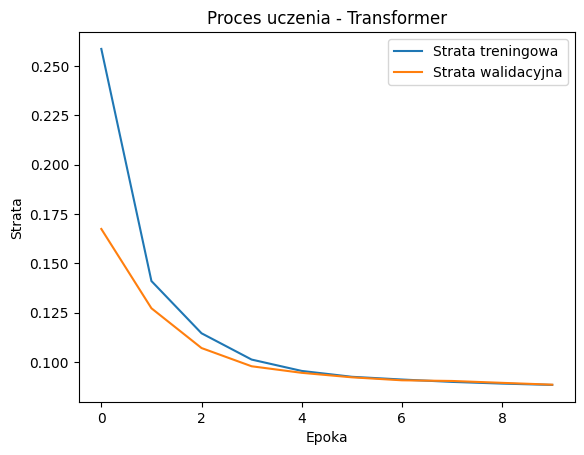

In [18]:
plt.plot(history.history['loss'], label='Strata treningowa')
plt.plot(history.history['val_loss'], label='Strata walidacyjna')

plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.legend()
plt.title("Proces uczenia - Transformer")
plt.show()